# Imports

In [1]:
import math
import os
import sys

import numpy as np
import torch
from torchvision.transforms import GaussianBlur
from IPython.core.pylabtools import figsize
from mpmath.identification import transforms
import matplotlib.pyplot as plt
from torchvision.transforms.v2 import RandomApply

from utils.checkpoint import load_checkpoint, save_checkpoint, load_model
from utils.data import get_dataloaders, get_img_from_loader
from evaluate import evaluate, evaluate_with_uncertainty

sys.path.append("..")

from models.lenet import Net as LeNet
from config import Config

from utils.corruptions import gaussian_blur, test_on_corruptions, corruptions_uncertainty
from utils.data import get_img_from_loader

plt.rcParams['axes.labelsize'] = 10  # Default font size for all axis labels

In [2]:
config = Config()
device = config.device

# Prepare data
_, val_loader, test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
    dataset='EMNIST',
    dataset_kwargs={"split": "letters"},
)

# Model
lenet_model = LeNet(
    prior_sigma1=math.exp(-0.8470609173270909),
    prior_sigma2=math.exp(-7.293222293379696),
    prior_pi=0.44622172885322486,
    num_classes=26,
    rho_init=-5.724956071835678
).to(device)

# Optimizer (needed to load checkpoint)
optimizer = torch.optim.Adam(lenet_model.parameters(), lr=config.learning_rate)
# Load weights
# config.model_name = 'mnist_bayesian_lenet'
config.model_name = 'lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1'
load_model(lenet_model, f'{config.checkpoint_path}/{config.model_name}/{config.model_name}_20260317.pth', device)

[model] Loaded from ../checkpoints/lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1/lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1_20260317.pth


# Corruptions and Uncertainty

In [3]:
torch.manual_seed(42)
corruptions = {
    'Original': lambda x: x,
    '$k=3$': lambda x: gaussian_blur(x, kernel_size=3),
    '$k=5$': lambda x: gaussian_blur(x, kernel_size=5),
    '$k=7$': lambda x: gaussian_blur(x, kernel_size=7),
    '$k=9$': lambda x: gaussian_blur(x, kernel_size=9),
}
T = 10

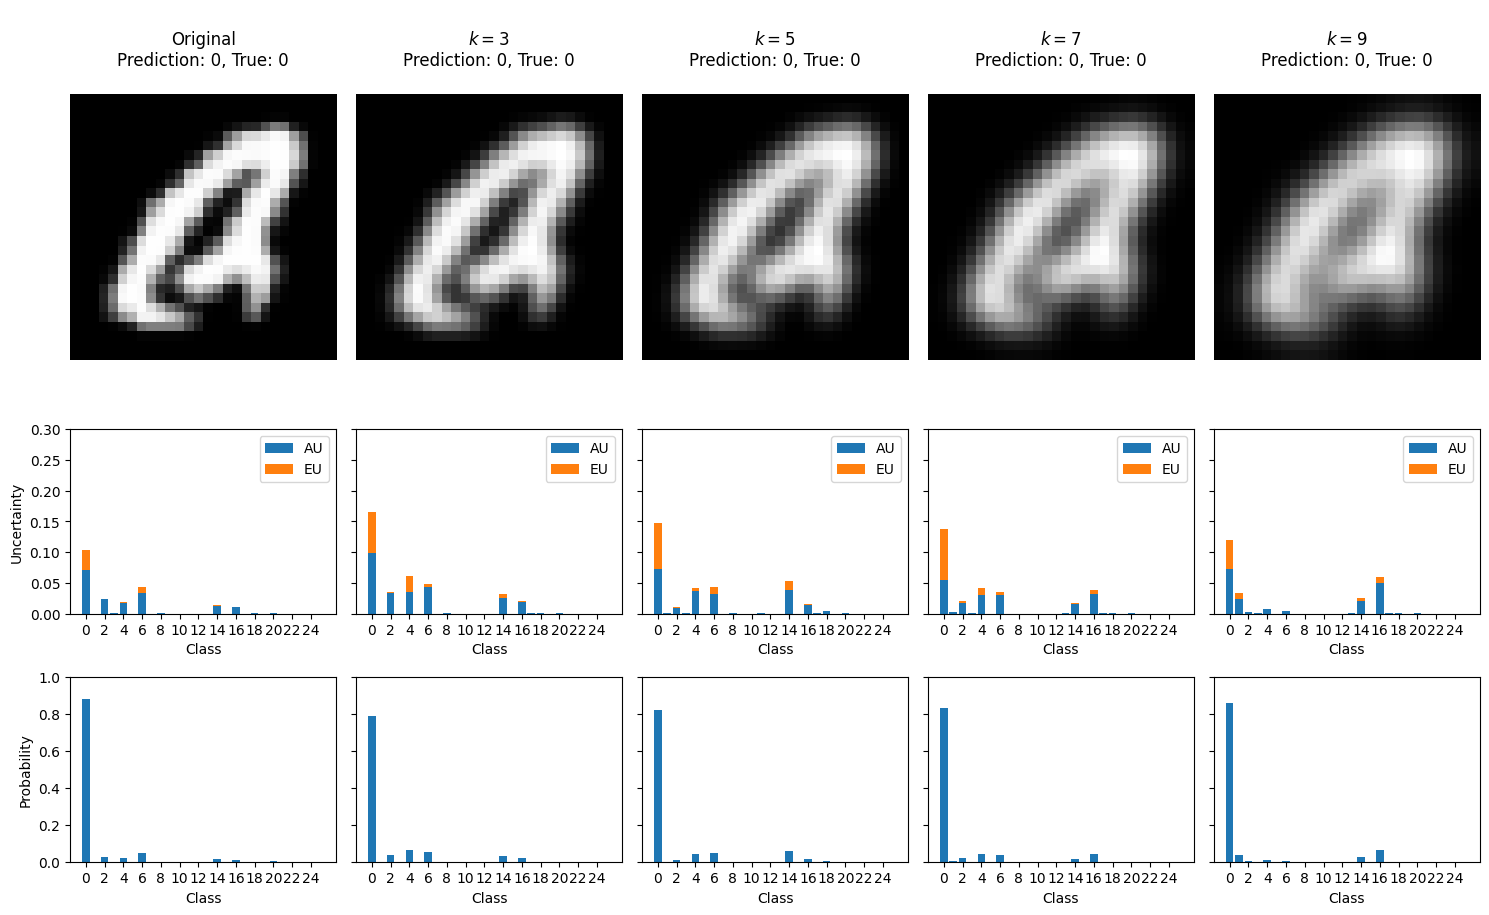

In [4]:
img, label = get_img_from_loader(test_loader, batch_idx=29, img_idx=3, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, num_classes=26, T=T)

Random batch index: 825, image index: 8


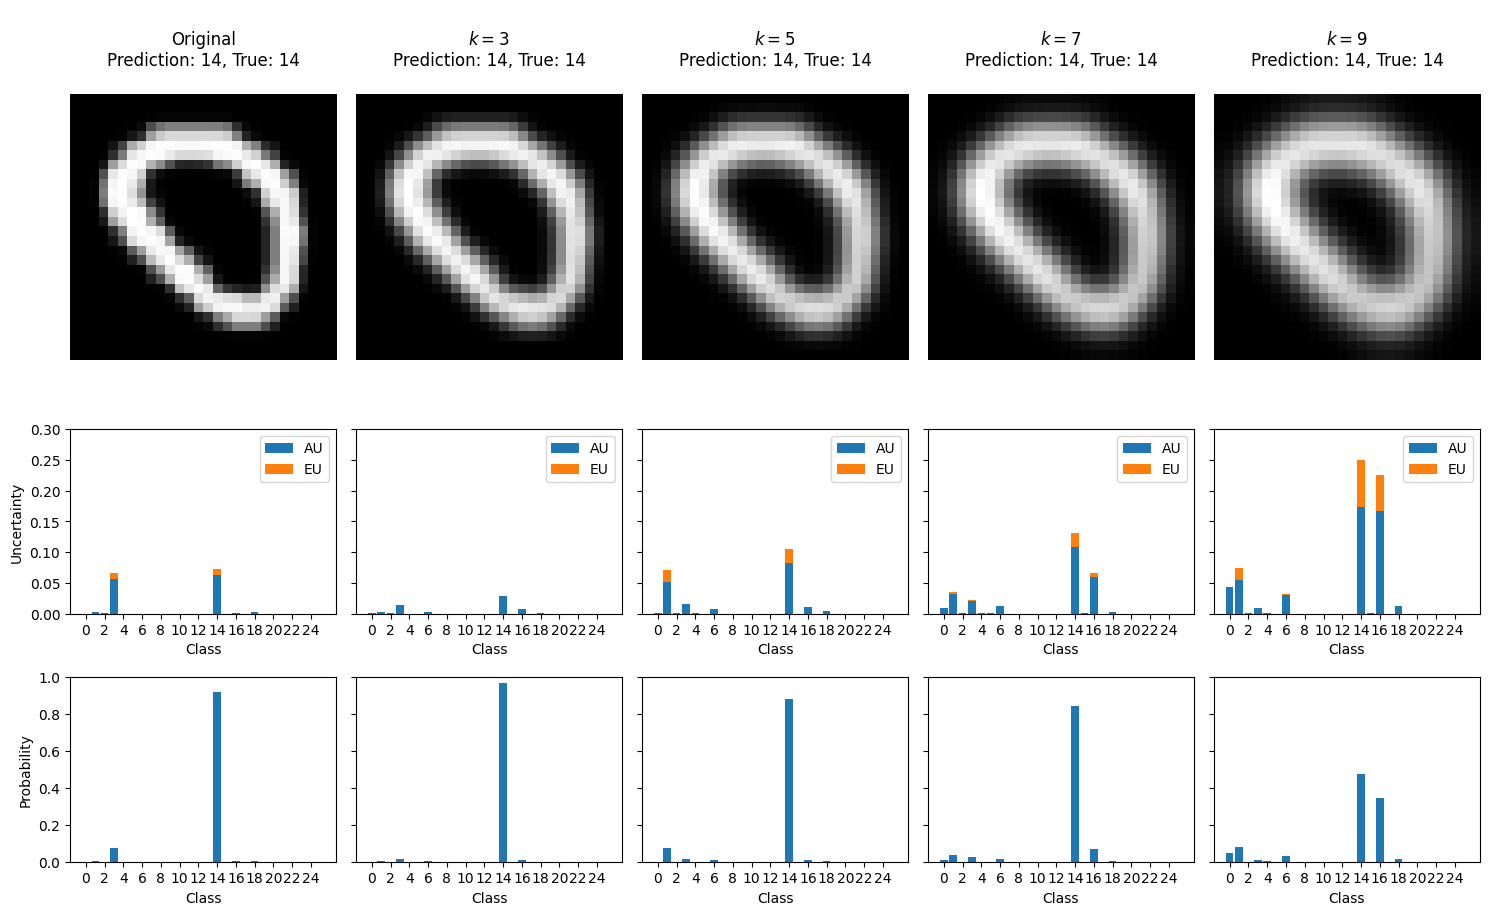

In [19]:
import random

rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
img, label = get_img_from_loader(test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, num_classes=26, T=T)

# Evaluate

In [11]:
import graphviz
from torchview import draw_graph

graphviz.set_jupyter_format('png')
graph = draw_graph(lenet_model,
                   input_size=(1, 1, 28, 28),
                   device=device,
                   graph_dir='TB',
                   save_graph=False,
                   graph_name='Bayesian LeNet-5')
graph.visual_graph

In [3]:
from train import test

loss, accuracy = test(lenet_model, test_loader, device, 0)
print(f"Loss: {loss:.6f}, Accuracy: {accuracy:.4f}")

Loss: 6.685663, Accuracy: 0.9223



Expected Calibration Error: 0.0115


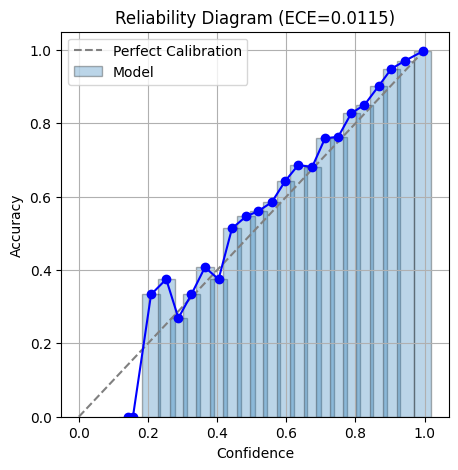

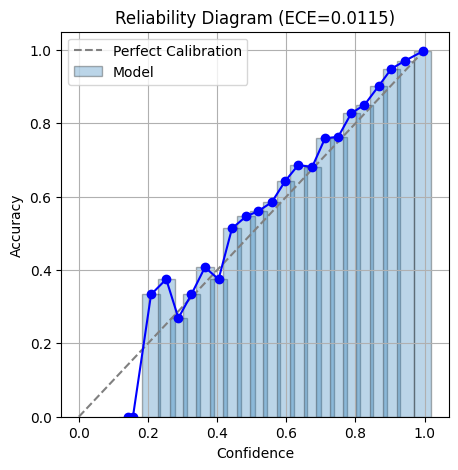

In [4]:
from utils.calibration import reliability_diagram
reliability_diagram(lenet_model, test_loader, device, T=20, n_bins=26, num_classes=26)

In [ ]:
from evaluate import evaluate_with_uncertainty

preds, (total, alea, epis) = evaluate_with_uncertainty(lenet_model, test_loader, device, mc_samples=20)
print(f"Total Uncertainty (mean): {total.mean().item()}")
print(f"Aleatoric (mean): {alea.mean().item()}")
print(f"Epistemic (mean): {epis.mean().item()}")

# Вычисление точности с гауссовским размытием

Calculating Accuracy and Uncertainties with Gaussian Blur: 100%|██████████| 4/4 [07:19<00:00, 109.80s/it]


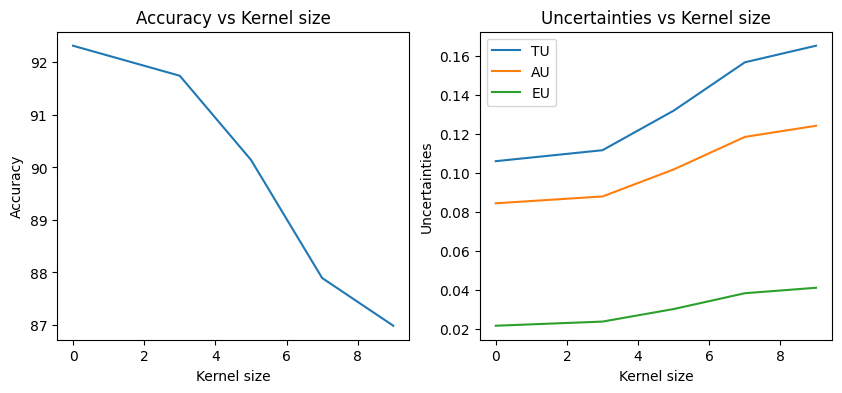

In [5]:
from tqdm import tqdm

kernel_sizes = [0, 3, 5, 7, 9]
accuracies = []
total_unc = []
alea_unc = []
epis_unc = []

original_test_accuracy = evaluate(lenet_model, test_loader, device=config.device)
_, uncertainties = evaluate_with_uncertainty(lenet_model, test_loader, device=config.device, mc_samples=10)
accuracies.append(original_test_accuracy)
total_unc.append(uncertainties[0].mean().item())
alea_unc.append(uncertainties[1].mean().item())
epis_unc.append(uncertainties[2].mean().item())

loop = tqdm(kernel_sizes[1:], desc=f"Calculating Accuracy and Uncertainties with Gaussian Blur")
for kernel_size in loop:
    blurred_test_loader = get_dataloaders(
        data_dir="../data",
        batch_size=config.test_batch_size,
        num_workers=config.num_workers,
        use_cuda=torch.cuda.is_available(),
        dataset="EMNIST",
        dataset_kwargs={"split": "letters"},
        extra_transforms=[
            GaussianBlur(kernel_size)
        ]
    )[2]  # Получаем только тестовый загрузчик

    test_accuracy = evaluate(lenet_model, blurred_test_loader, device=config.device)
    _, uncertainties = evaluate_with_uncertainty(lenet_model, blurred_test_loader, device=config.device, mc_samples=10)
    accuracies.append(test_accuracy)
    total_unc.append(uncertainties[0].mean().item())
    alea_unc.append(uncertainties[1].mean().item())
    epis_unc.append(uncertainties[2].mean().item())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(kernel_sizes, accuracies)
axes[0].set_title("Accuracy vs Kernel size")
axes[0].set_ylabel("Accuracy")

axes[1].plot(kernel_sizes, total_unc, label='TU')
axes[1].plot(kernel_sizes, alea_unc, label='AU')
axes[1].plot(kernel_sizes, epis_unc, label='EU')
axes[1].set_title("Uncertainties vs Kernel size")
axes[1].set_ylabel("Uncertainties")
axes[1].legend()

for i in range(2):
    axes[i].set_xlabel("Kernel size")
plt.show()

# Зависимость неопределенности модели от правильности предсказаний

In [3]:
# Анализ корреляции между неопределенностью и правильностью предсказаний для разных уровней размытия
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.transforms import GaussianBlur
from utils.uncertainty import mc_predict, quantify_uncertainties

T = 10
kernel_sizes = [0, 1, 3, 5, 7, 9]
# kernel_sizes = [0, 1, 3, 7]
correlations = []
mean_unc_correct = []
mean_unc_incorrect = []
mean_aunc_correct = []
mean_aunc_incorrect = []
mean_eunc_correct = []
mean_eunc_incorrect = []

lenet_model.eval()

for ks in kernel_sizes:
    if ks == 0:
        current_loader = test_loader
        desc = "Original"
    else:
        current_loader = get_dataloaders(
            data_dir="../data",
            batch_size=config.test_batch_size,
            num_workers=config.num_workers,
            use_cuda=torch.cuda.is_available(),
            dataset="EMNIST",
            dataset_kwargs={"split": "letters"},
            extra_transforms=[GaussianBlur(ks)]
        )[2]
        desc = f"Blur {ks}"

    all_correct = []
    all_conf = []
    all_uncertainties = []
    all_aleatoric = []
    all_epistemic = []

    print(f"Processing {desc}...")
    for x, y in tqdm(current_loader, leave=False):
        x, y = x.to(device), y.to(device)

        # Оценка неопределенности
        mc_preds = mc_predict(lenet_model, x, mc_samples=T)
        preds, (total_unc_mat, alea_unc_mat, _) = quantify_uncertainties(mc_preds)

        # Извлекаем диагональ (дисперсию для каждого класса) и суммируем
        unc = total_unc_mat.diagonal(dim1=1, dim2=2).sum(-1)
        aunc = alea_unc_mat.diagonal(dim1=1, dim2=2).sum(-1)
        correct = (preds == y).float()

        # Softmax probability of the predicted class (mean over MC samples)
        mean_probs = mc_preds.mean(0)  # [batch, num_classes]
        pred_conf = mean_probs[torch.arange(len(preds)), preds]  # [batch]
        true_conf = mean_probs[torch.arange(len(y)), y]  # [batch]

        all_correct.append(correct.cpu().numpy())
        all_conf.append(pred_conf.cpu().numpy())
        all_uncertainties.append(unc.cpu().numpy())
        all_aleatoric.append(aunc.cpu().numpy())
        all_epistemic.append((unc - aunc).cpu().numpy())

    c_vec = np.concatenate(all_correct)
    conf_vec = np.concatenate(all_conf)
    u_vec = np.concatenate(all_uncertainties)
    au_vec = np.concatenate(all_aleatoric)
    eu_vec = np.concatenate(all_epistemic)
    eunc_mean = np.mean(eu_vec)
    aunc_mean = np.mean(au_vec)
    print(f"Kernel {ks}: E[epistemic]={eunc_mean:.6f}, E[aleatoric]={aunc_mean:.6f}, ratio={eunc_mean/aunc_mean:.4f}")

    # Считаем корреляцию (softmax confidence of predicted class vs uncertainty)
    corr = np.corrcoef(conf_vec, u_vec)[0, 1]
    correlations.append(corr)

    # Считаем среднюю неопределенность для верных и неверных ответов
    mean_unc_correct.append(u_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mean_unc_incorrect.append(u_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)
    mean_aunc_correct.append(au_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mean_aunc_incorrect.append(au_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)
    mean_eunc_correct.append(eu_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mean_eunc_incorrect.append(eu_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)

Processing Original...


Kernel 0: E[epistemic]=0.021894, E[aleatoric]=0.084282, ratio=0.2598
Processing Blur 1...


Kernel 1: E[epistemic]=0.021478, E[aleatoric]=0.084289, ratio=0.2548
Processing Blur 3...


Kernel 3: E[epistemic]=0.023558, E[aleatoric]=0.087757, ratio=0.2684
Processing Blur 5...


Kernel 5: E[epistemic]=0.030167, E[aleatoric]=0.101678, ratio=0.2967
Processing Blur 7...


Kernel 7: E[epistemic]=0.037965, E[aleatoric]=0.117354, ratio=0.3235
Processing Blur 9...


Kernel 9: E[epistemic]=0.041499, E[aleatoric]=0.125483, ratio=0.3307


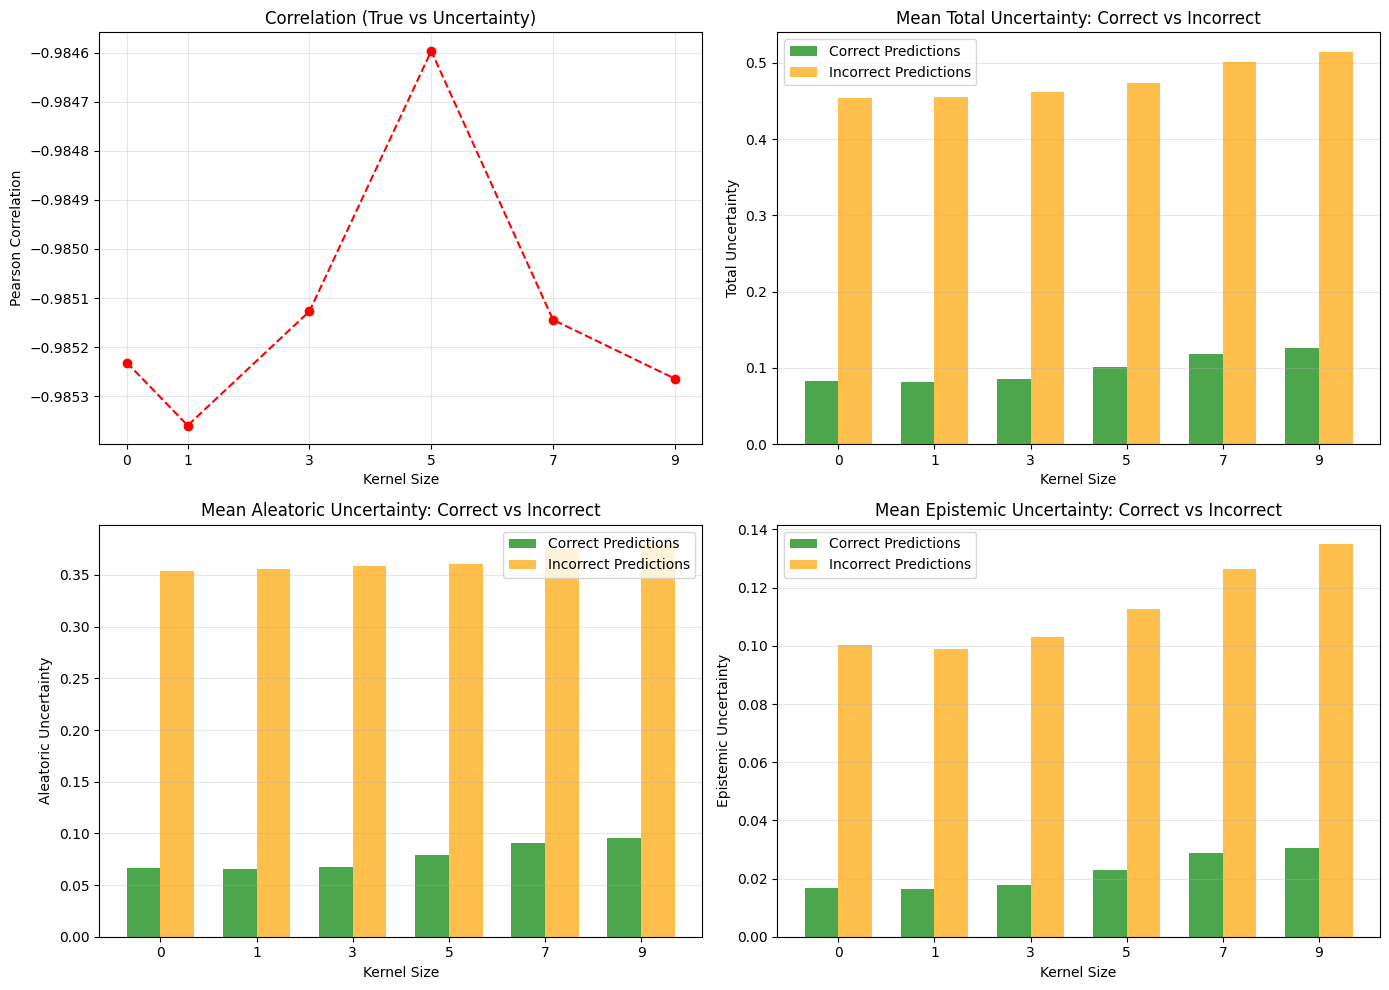

Kernel 0: Correlation = -0.9852, Unc Ratio (Err/Corr) = 5.49x
	Alea Unc Ratio (Err/Corr) = 5.35x, Unc Ratio (Err/Corr) = 6.04x
Kernel 1: Correlation = -0.9854, Unc Ratio (Err/Corr) = 5.53x
	Alea Unc Ratio (Err/Corr) = 5.39x, Unc Ratio (Err/Corr) = 6.10x
Kernel 3: Correlation = -0.9851, Unc Ratio (Err/Corr) = 5.39x
	Alea Unc Ratio (Err/Corr) = 5.28x, Unc Ratio (Err/Corr) = 5.81x
Kernel 5: Correlation = -0.9846, Unc Ratio (Err/Corr) = 4.66x
	Alea Unc Ratio (Err/Corr) = 4.58x, Unc Ratio (Err/Corr) = 4.93x
Kernel 7: Correlation = -0.9851, Unc Ratio (Err/Corr) = 4.22x
	Alea Unc Ratio (Err/Corr) = 4.16x, Unc Ratio (Err/Corr) = 4.41x
Kernel 9: Correlation = -0.9853, Unc Ratio (Err/Corr) = 4.07x
	Alea Unc Ratio (Err/Corr) = 3.96x, Unc Ratio (Err/Corr) = 4.40x


In [4]:
# Визуализация результатов
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x_labels = [str(k) for k in kernel_sizes]
x = np.arange(len(kernel_sizes))
titles = ['Total', 'Aleatoric', 'Epistemic']
incorrect = [mean_unc_incorrect, mean_aunc_incorrect, mean_eunc_incorrect]
correct = [mean_unc_correct, mean_aunc_correct, mean_eunc_correct]

# График 1: Коэффициент корреляции
axes[0, 0].plot(kernel_sizes, correlations, marker='o', color='red', linestyle='--')
axes[0, 0].set_title("Correlation (True vs Uncertainty)")
axes[0, 0].set_xticks(kernel_sizes)
axes[0, 0].set_xlabel("Kernel Size")
axes[0, 0].set_ylabel("Pearson Correlation")
axes[0, 0].grid(True, alpha=0.3)

# График 2: Сравнение неопределенности для Correct vs Incorrect
for i, ax in enumerate(axes.flatten()[1:]):
    width = 0.35
    ax.bar(x - width/2, correct[i], width, label='Correct Predictions', color='green', alpha=0.7)
    ax.bar(x + width/2, incorrect[i], width, label='Incorrect Predictions', color='orange', alpha=0.7)
    ax.set_title(f"Mean {titles[i]} Uncertainty: Correct vs Incorrect")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel("Kernel Size")
    ax.set_ylabel(f"{titles[i]} Uncertainty")
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

for i, ks in enumerate(kernel_sizes):
    print(f"Kernel {ks}: Correlation = {correlations[i]:.4f}, Unc Ratio (Err/Corr) = {mean_unc_incorrect[i]/mean_unc_correct[i]:.2f}x")
    print(f"\tAlea Unc Ratio (Err/Corr) = {mean_aunc_incorrect[i]/mean_aunc_correct[i]:.2f}x, Unc Ratio (Err/Corr) = {mean_eunc_incorrect[i]/mean_eunc_correct[i]:.2f}x")


# Зависимость неопределенности от уровня и типа искажений

In [3]:
corruptions = {
    'Original': lambda x: x,
    # 'WeakBlur': lambda x: gaussian_blur(x, kernel_size=3),
    'MediumBlur': lambda x: gaussian_blur(x, kernel_size=5),
    # 'StrongBlur': lambda x: gaussian_blur(x, kernel_size=7),
    'VeryStrongBlur': lambda x: gaussian_blur(x, kernel_size=9),
}

In [11]:
letters_map = {i: chr(97 + i) for i in range(26)}

Random batch index: 875, image index: 3
IMG[875, 3]=p


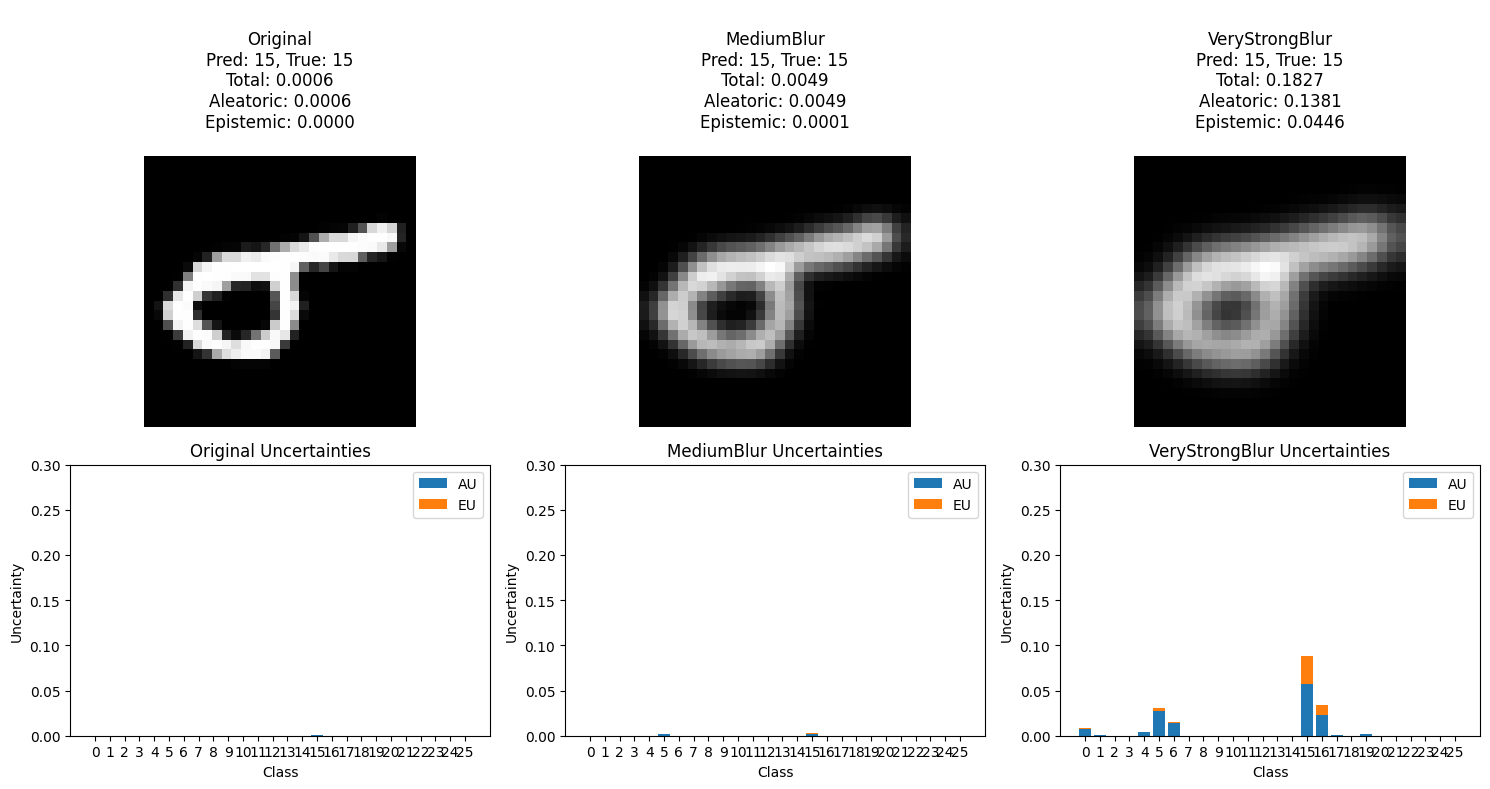

In [16]:
import random

rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
img, label = get_img_from_loader(test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, device=config.device)
print(f'IMG[{rand_batch_idx}, {rand_img_idx}]={letters_map[label.item()]}')
corruptions_uncertainty(lenet_model, img, label, corruptions, num_classes=26, T=20)

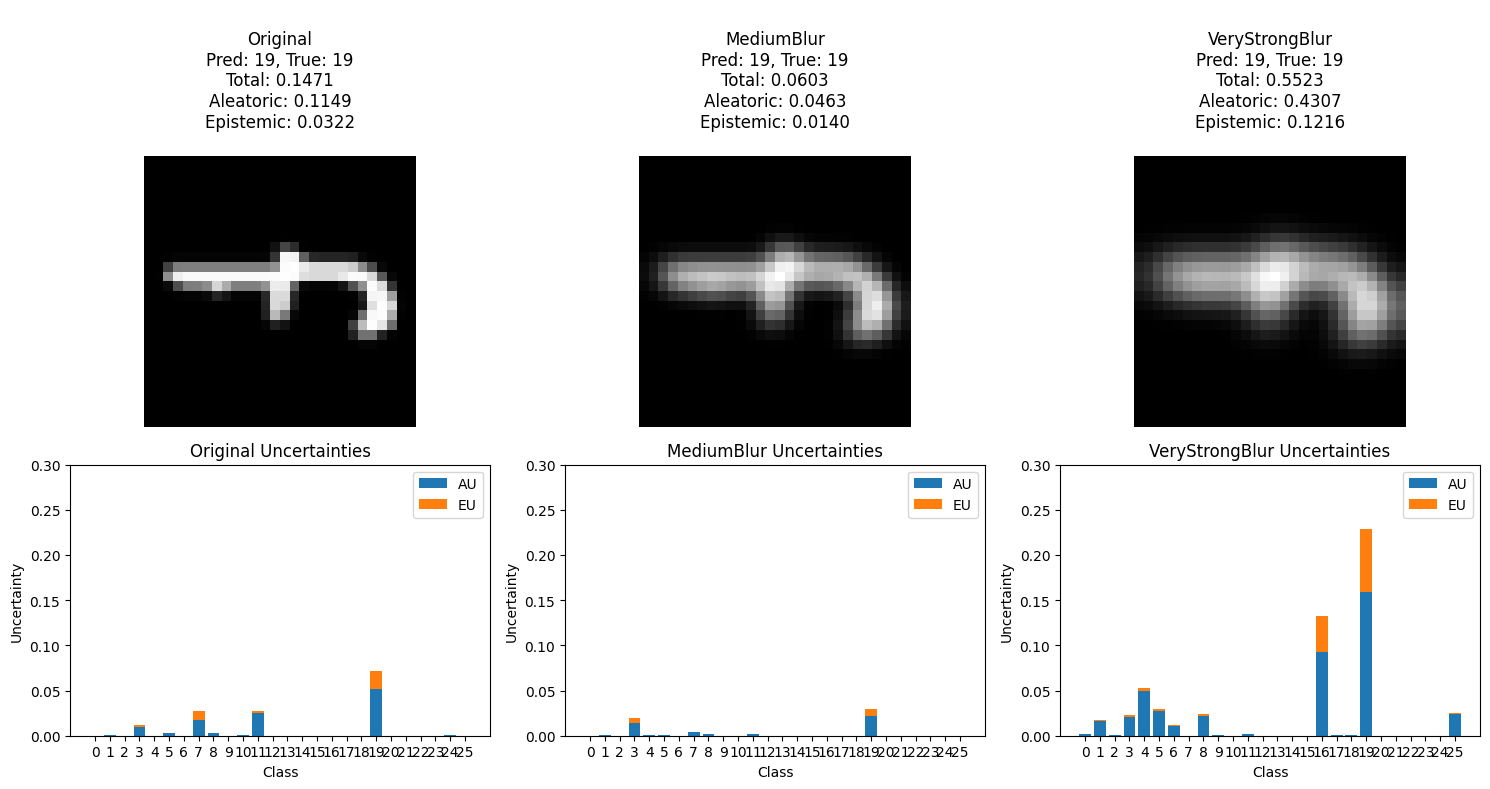

In [15]:
img, label = get_img_from_loader(test_loader, batch_idx=1089, img_idx=2, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, num_classes=26, T=20)

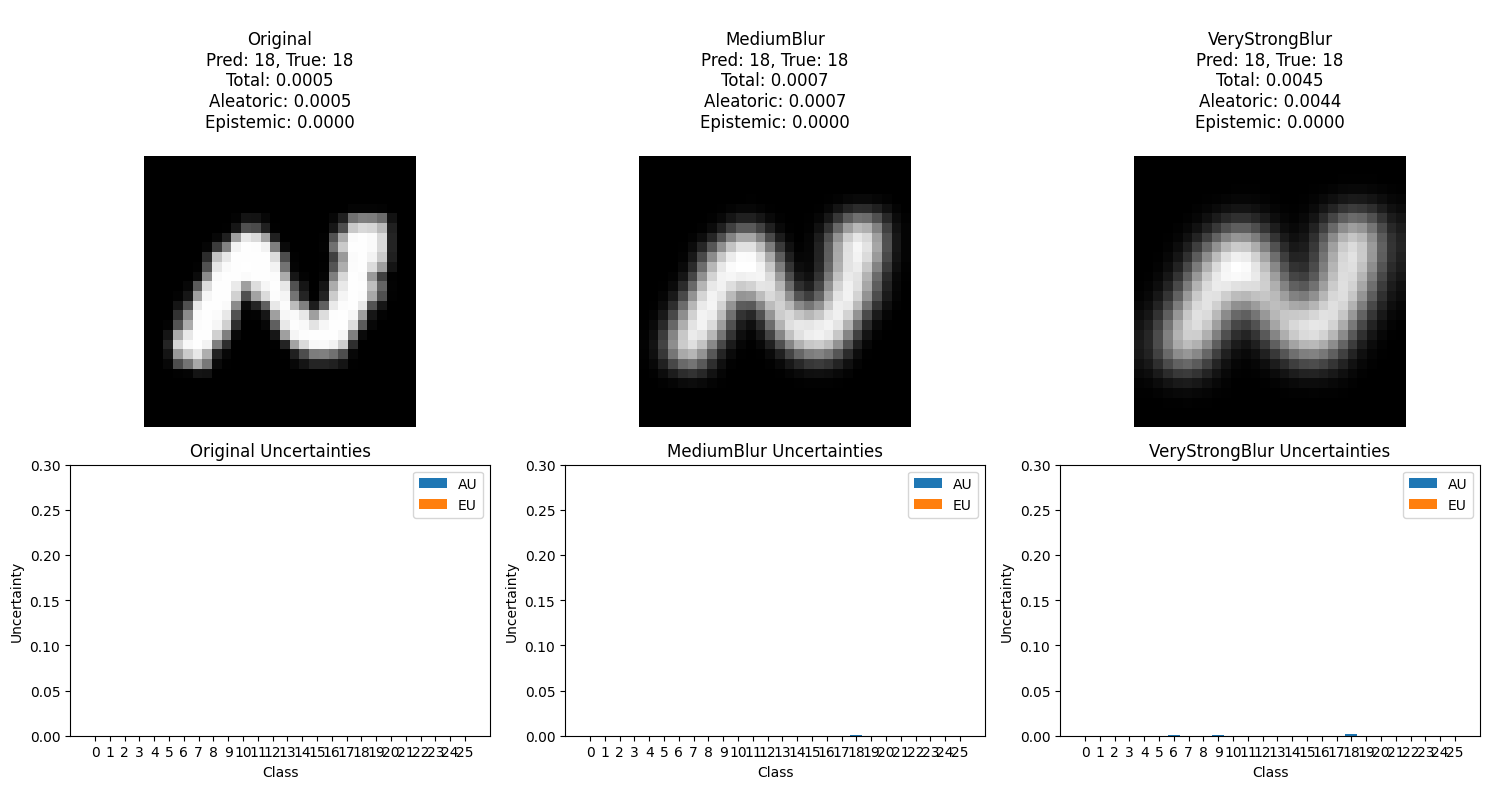

In [12]:
img, label = get_img_from_loader(test_loader, batch_idx=1036, img_idx=9, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, num_classes=26, T=20)

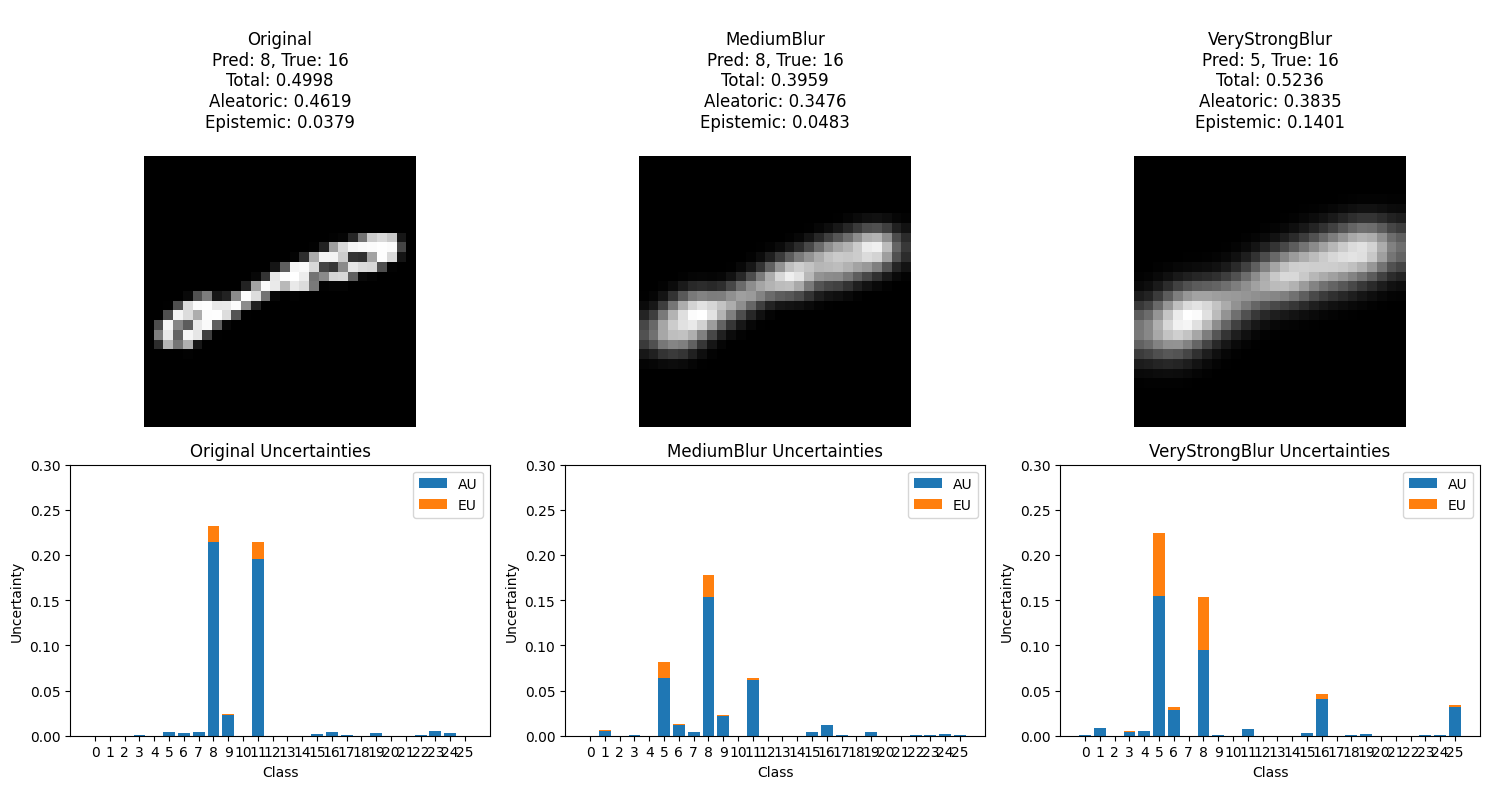

In [6]:
img, label = get_img_from_loader(test_loader, batch_idx=965, img_idx=1, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, num_classes=26, T=20)

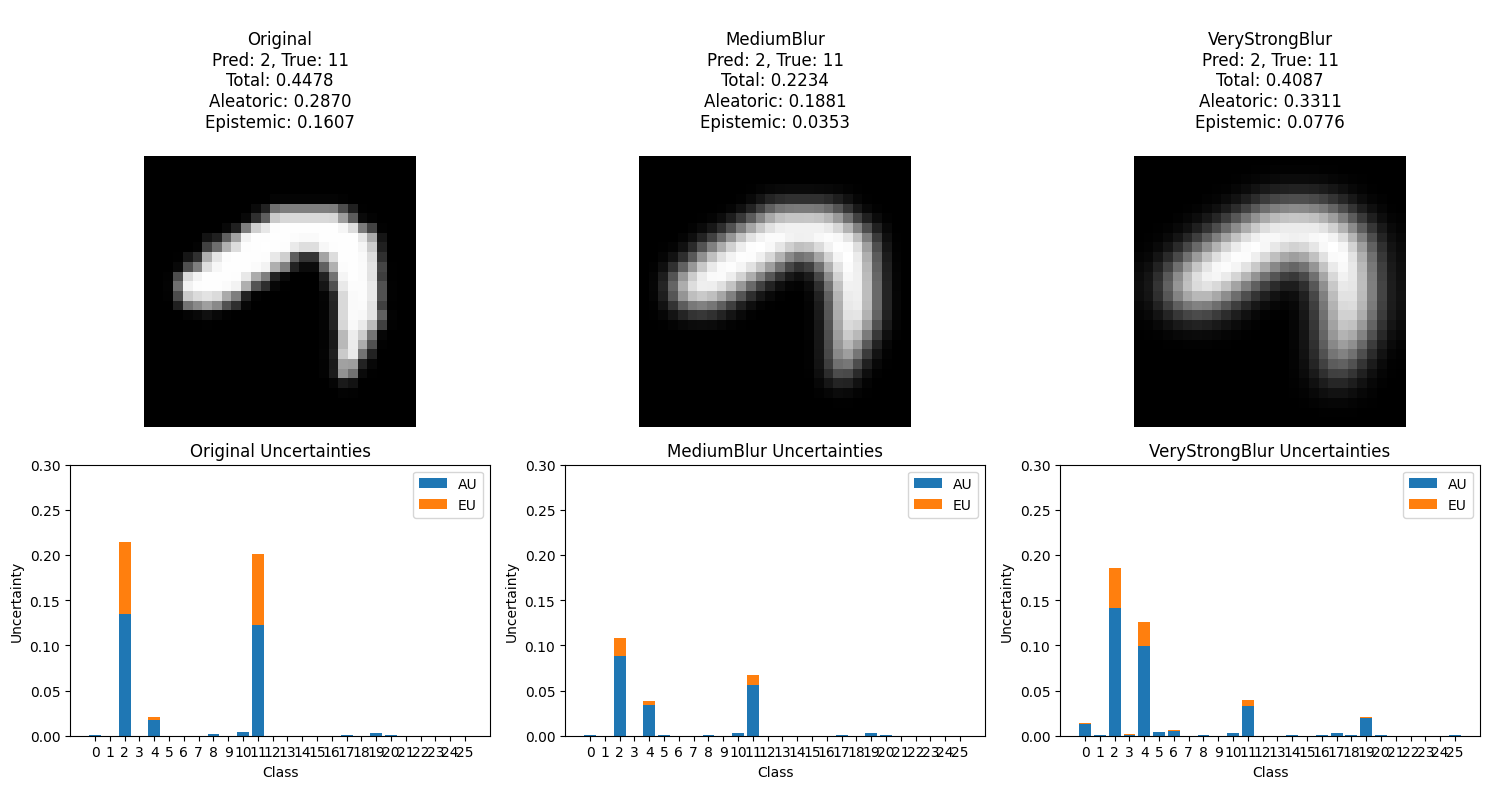

In [7]:
img, label = get_img_from_loader(test_loader, batch_idx=677, img_idx=10, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, num_classes=26, T=20)

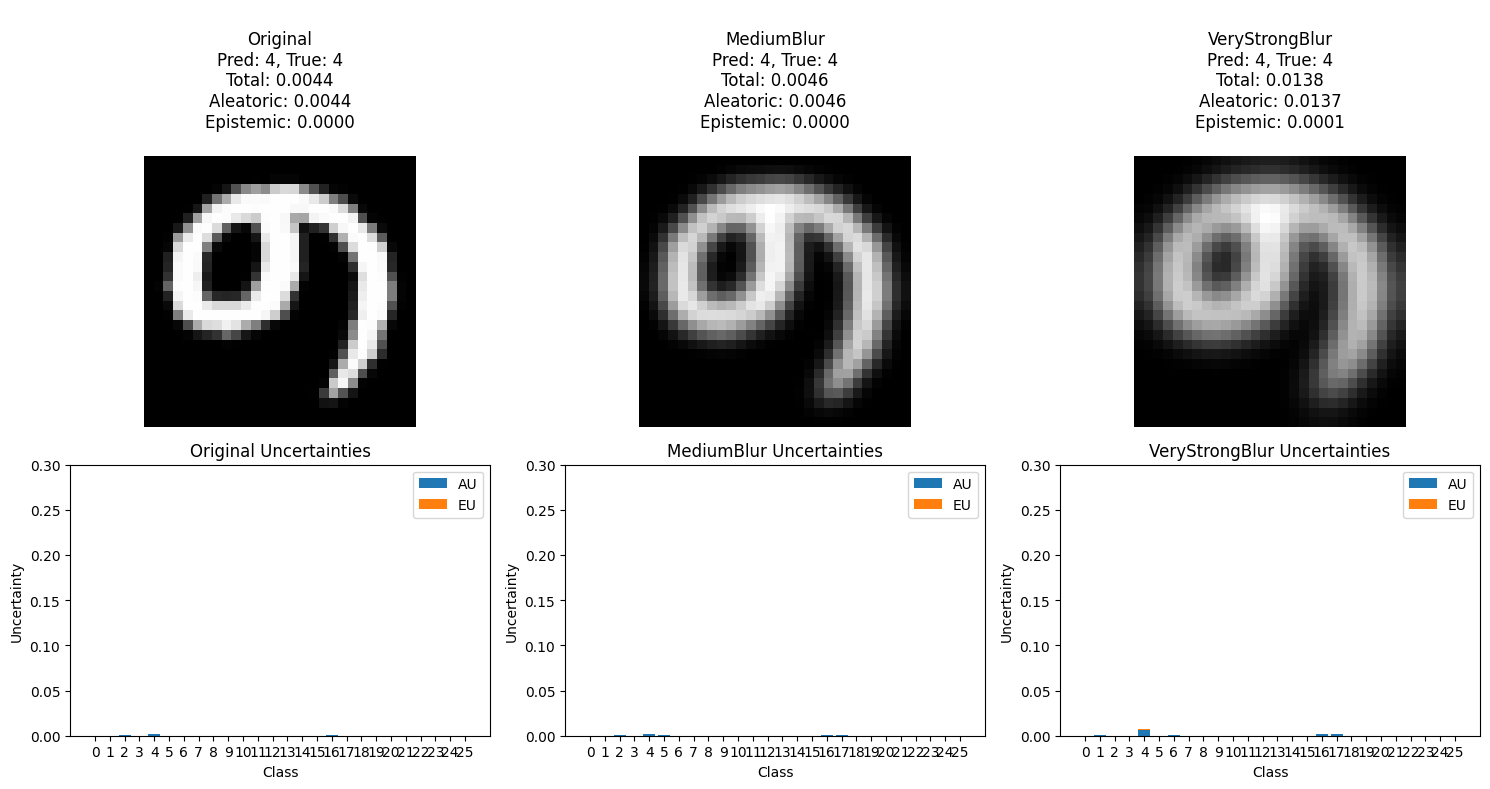

In [8]:
img, label = get_img_from_loader(test_loader, batch_idx=285, img_idx=5, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, num_classes=26, T=20)

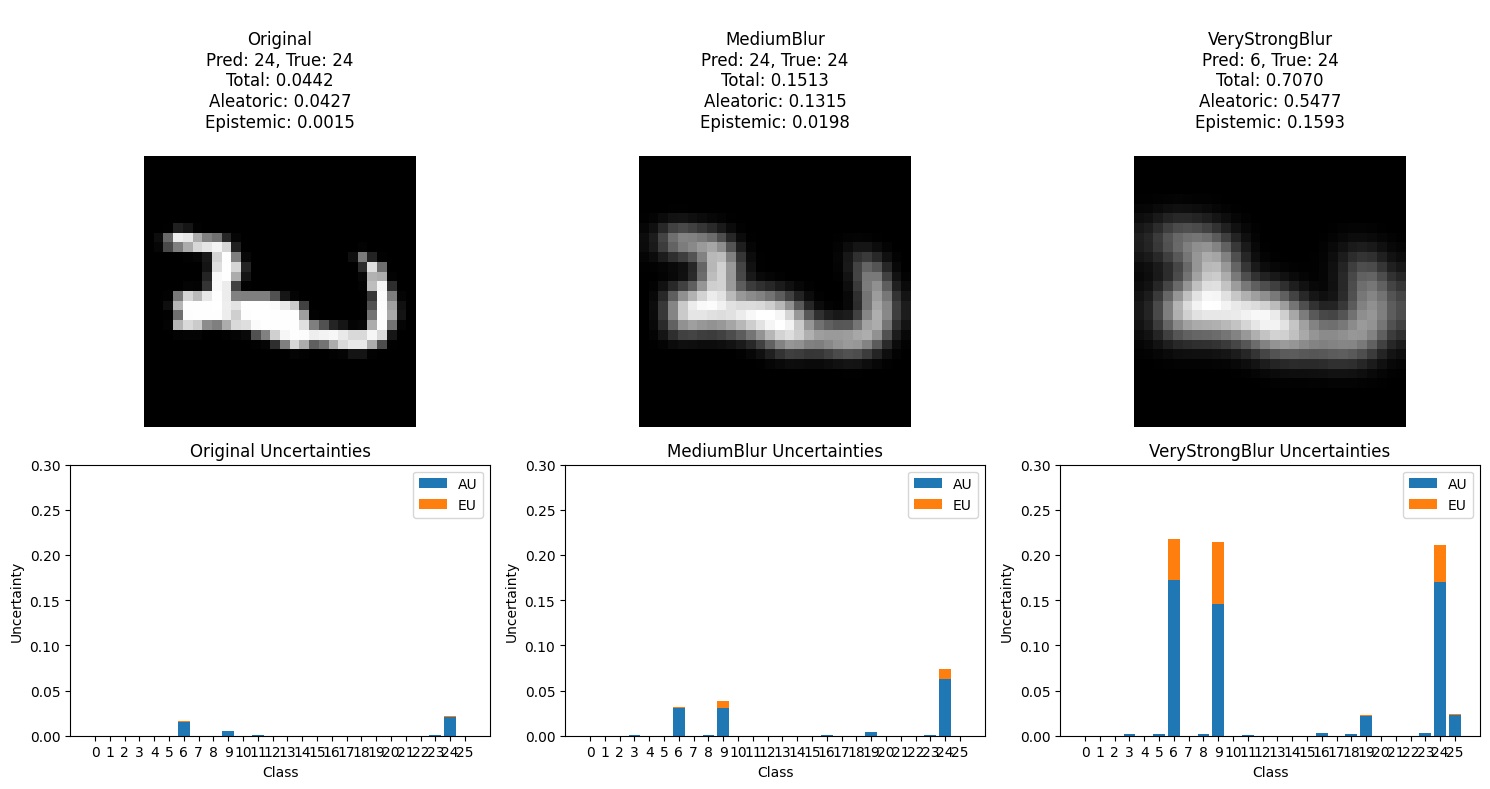

In [9]:
img, label = get_img_from_loader(test_loader, batch_idx=1394, img_idx=12, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, num_classes=26, T=20)

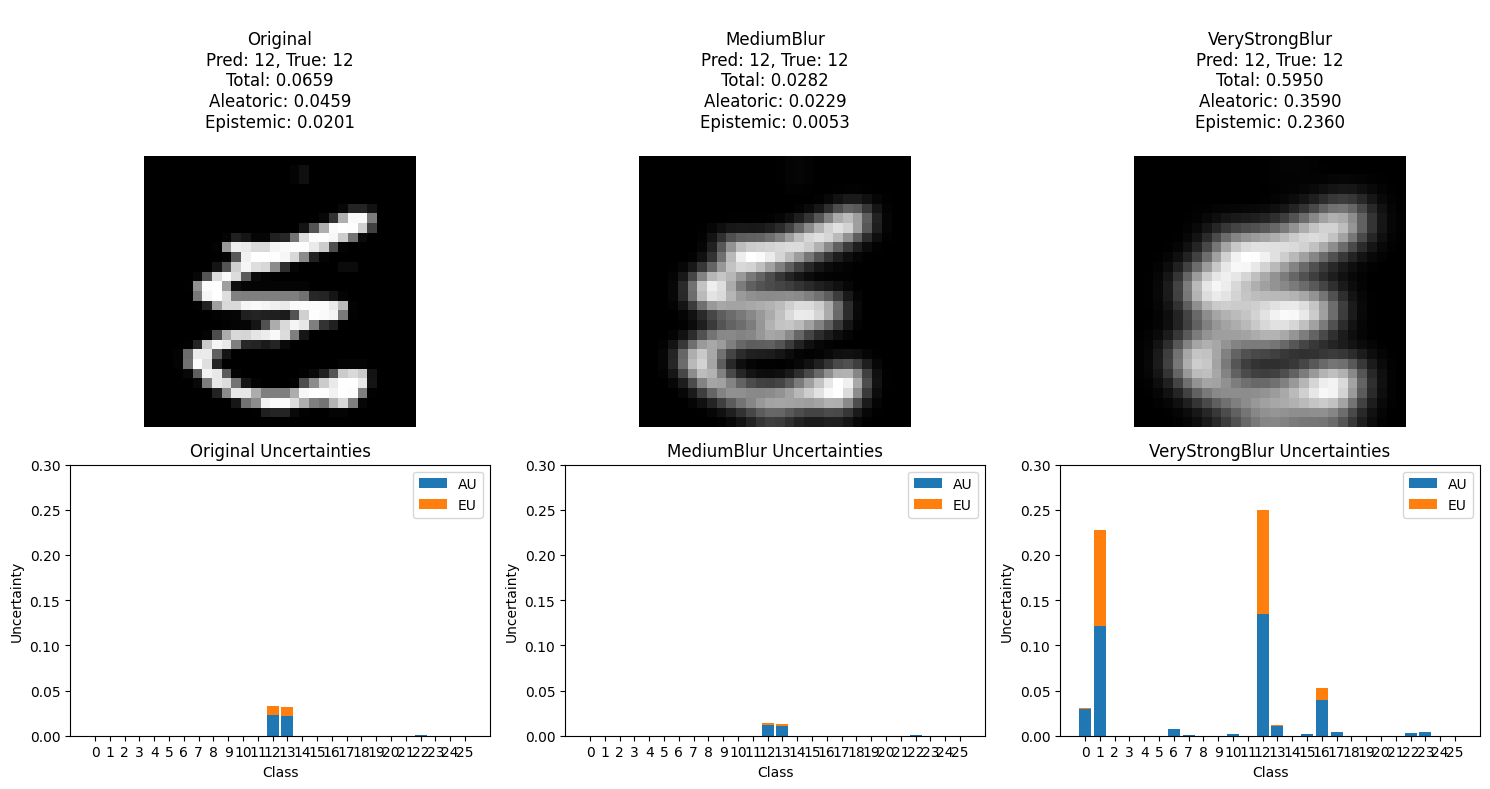

In [10]:
img, label = get_img_from_loader(test_loader, batch_idx=717, img_idx=1, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, num_classes=26, T=20)